In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import phoebe
from phoebe import u as _u

# ---------------------------
# RUTAS A TUS ARCHIVOS
# ---------------------------
filepath_r = "C:/Users/darkm/Desktop/archivos_Investigación/PHOEBE}/TYC_6265_2079_flujo_r.txt"
filepath_i = "C:/Users/darkm/Desktop/archivos_Investigación/PHOEBE}/TYC_6265_2079_flujo_i.txt"

In [3]:
data_r = np.genfromtxt(filepath_r, delimiter=None, skip_header=1, encoding='latin1')
time_r = data_r[:, 0]
flux_r = data_r[:, 1]
fluxerr_r = data_r[:, 2]

data_i = np.genfromtxt(filepath_i, delimiter=None, skip_header=1, encoding='latin1')
time_i = data_i[:, 0]
flux_i = data_i[:, 1]
fluxerr_i = data_i[:, 2]


In [4]:
b = phoebe.default_binary()

# Agregar datasets
b.add_dataset('lc', times=time_r, fluxes=flux_r, sigmas=fluxerr_r,
              passband='SDSS:r', dataset='lc01')

b.add_dataset('lc', times=time_i, fluxes=flux_i, sigmas=fluxerr_i,
              passband='SDSS:i', dataset='lc02')

# ---------------------------
# PARÁMETROS INICIALES (los tuyos)
# ---------------------------
b['period@binary'] = 3.6788 * u.day
# Usamos el primer tiempo como referencia (puedes cambiar t0 a un valor mejor)
b['t0_supconj@binary'] = time_r[0] * u.day
b['incl@binary'] = 70.0 * u.deg
b['q@binary'] = 0.5
b['teff@primary'] = 25700 * u.K
b['teff@secondary'] = 20000 * u.K
b['ecc@binary'] = 0.0


b.set_value_all('atm', 'ck2004')
b.set_value_all('ld_mode', 'interp')
b.set_value_all('ld_mode_bol', 'manual')
b.set_value_all('gravb_bol', 0.25)
b.set_value_all('irrad_frac_refl_bol', 1.0)
b.set_value_all('pblum_mode', 'dataset-scaled')
b.set_value_all('irrad_method', 'horvat')

# Constraints (como ya tenías)
b.flip_constraint('teffratio', solve_for='teff@secondary')
b.flip_constraint('requivsumfrac', solve_for='requiv@secondary')


<ConstraintParameter: {requiv@secondary@component} = ({requivsumfrac@binary@component} * {sma@binary@component}) - {requiv@primary@component} (solar units) => 1.0 solRad>

In [5]:
b.add_solver('estimator.ebai', ebai_method='knn', solver='ebai_knn')
b.run_solver('ebai_knn', solution='ebai_knn_solution')


C:\Users\darkm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsRegressor from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\darkm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


<ParameterSet: 13 parameters | qualifiers: fitted_twigs, fitted_units, comments, ebai_fluxes, adopt_distributions, input_phases, orbit, input_sigmas, fitted_values, adopt_parameters, adopt_values, ebai_phases, input_fluxes>

In [6]:
print(b.adopt_solution('ebai_knn_solution', trial_run=True))

ParameterSet: 6 parameters
   t0_supconj@binary@orbit@com...: 56458.003937 d
   teffratio@binary@orbit@comp...: 0.9095312691517681
   requivsumfrac@binary@orbit@...: 0.29910399465803
     esinw@binary@orbit@component: -0.07604380001578544
     ecosw@binary@orbit@component: -0.02742315024119257
      incl@binary@orbit@component: 78.11938695015135 deg


In [7]:
b.adopt_solution('ebai_knn_solution',
                 adopt_parameters=[
                     't0_supconj',
                     'incl',
                     'period@binary',
                     'teff@primary',        
                     'teffratio',          
                     'requivratio@binary',
                     'requivsumfrac@binary',
                 ],
                 adopt_values=True)


<ParameterSet: 20 parameters | contexts: dataset, component>

In [8]:
print(b.adopt_solution('ebai_knn_solution', trial_run=True))

ParameterSet: 6 parameters
   t0_supconj@binary@orbit@com...: 56458.003937 d
   teffratio@binary@orbit@comp...: 0.9095312691517681
   requivsumfrac@binary@orbit@...: 0.29910399465803
     esinw@binary@orbit@component: -0.07604380001578544
     ecosw@binary@orbit@component: -0.02742315024119257
      incl@binary@orbit@component: 78.11938695015135 deg


In [9]:
b.run_compute(model='modelo_ajustado', irrad_method='horvat')


100%|██████████| 167/167 [00:04<00:00, 36.53it/s]


<ParameterSet: 7 parameters | datasets: lc01, lc02>

C:\Users\darkm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\phoebe\dependencies\autofig\call.py:1305: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  artist = ax.scatter(*datapoint,


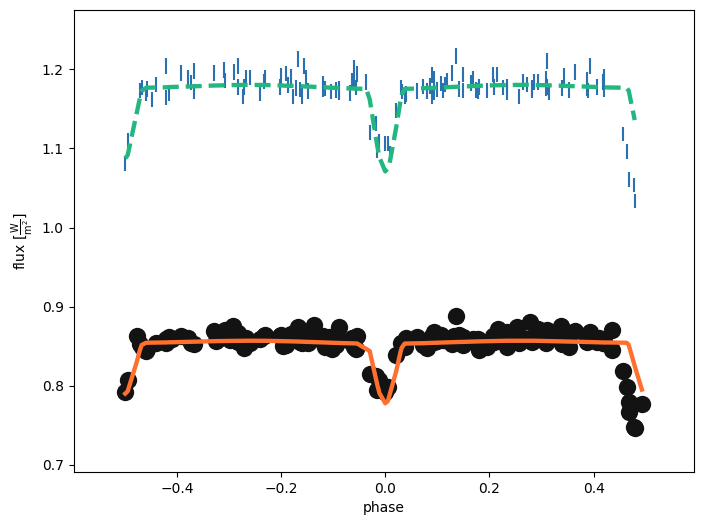

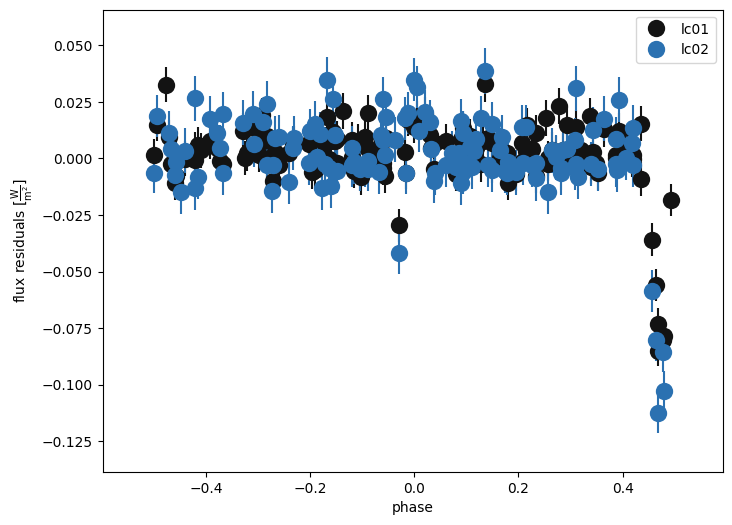

(<autofig.figure.Figure | 1 axes | 2 call(s)>,
 <Figure size 800x600 with 1 Axes>)

In [10]:
b.plot(dataset=['lc01', 'lc02'], x='phase', show=True)
b.plot(kind='lc', x='phases', y='residuals', show=True, legend=True, marker = 'o')

In [11]:
print("R1 (requiv@primary)=", b.get_value('requiv@primary@component'))
print("R2 (requiv@secondary)=", b.get_value('requiv@secondary@component'))

print("Sum (R1+R2)/a=", b.get_value('requivsumfrac@binary@component'))

print("Ratio R1/R2=", b.get_value('requivratio@binary@component'))

print("Teff primary=", b.get_value('teff@primary@component'))
print("Teff secondary=", b.get_value('teff@secondary@component'))

print("Incl=", b.get_value('incl@binary@orbit@component'))
print("Period=", b.get_value('period@binary'))

RL1 = b.get_value('requiv_max@primary@component')
RL2 = b.get_value('requiv_max@secondary@component')
print("Roche lobe 1:", RL1)
print("Roche lobe 2:", RL2)


R1 (requiv@primary)= 1.0
R2 (requiv@secondary)= 0.585251171687559
Sum (R1+R2)/a= 0.29910399465803
Ratio R1/R2= 0.585251171687559
Teff primary= 25700.0
Teff secondary= 23374.95361720044
Incl= 78.11938695015135
Period= 3.6788
Roche lobe 1: 2.342509738772878
Roche lobe 2: 1.6994519588420407


In [22]:
sol = b.get_solution('ebai_knn_solution')
print(sol)

ParameterSet: 13 parameters
R  orbit@ebai_knn_solution@sol...: binary
R  input_phases@ebai_knn_solut...: [-0.40969664 -0.39202185
 -0.39202185 ... -0.41986436
 -0.41464255 -0.41464255]
R  input_fluxes@ebai_knn_solut...: [1.00225222 1.00730541 1.01574343
 ... 1.02268247 0.9934551
 1.00516527]
R  input_sigmas@ebai_knn_solut...: [0.00895283 0.00899836 0.00842725
 ... 0.00847311 0.00828114
 0.00897968]
R  ebai_phases@ebai_knn_soluti...: [-0.5    0.505  0.51  ...  0.49
  0.495  0.5  ]
R  ebai_fluxes@ebai_knn_soluti...: [0.91734222 0.94100864 0.97046683
 ... 0.88738466 0.89946756
 0.91734222]
R  fitted_twigs@ebai_knn_solut...: ['t0_supconj@binary@orbit@component' 'teffratio@binary@orbit@component'
 'requivsumfrac@binary@orbit@component' 'esinw@binary@orbit@component'
 'ecosw@binary@orbit@component' 'incl@binary@orbit@component']
R  fitted_values@ebai_knn_solu...: [np.float64(56458.003937) np.float64(0.9095312691517681)
 np.float64(0.29910399465803) np.float64(-0.07604380001578544)
 np.float6

In [ ]:
sol = b.get_solution('ebai_knn_solution')
params_to_adopt = sol.get_value('adopt_parameters')

# Filtrar ecosw y esinw
params_filtered = [
    p for p in params_to_adopt
    if not ("ecosw" in p or "esinw" in p)
]

b.adopt_solution('ebai_knn_solution', adopt_parameters=params_filtered, adopt_values=True)

AttributeError: 'ParameterSet' object has no attribute 'adopt_parameters'